<a href="https://colab.research.google.com/github/PraneetVR/Asthma-Diagnosis-with-ANN/blob/main/DLSS_PROJECT_25DL365.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import plotly.express as px
import pandas as pd
import seaborn as sns

In [ ]:
url="/content/drive/MyDrive/25DLS365_DLSS Project Folder/processed-data.csv"
df=pd.read_csv(url)
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Severity_Mild,Severity_Moderate,Severity_None
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0


In [ ]:
df['sev'] = df['Severity_Mild'].astype(int) + df['Severity_Moderate'].astype(int)
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Severity_Mild,Severity_Moderate,Severity_None,sev
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0,1
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0,1


In [ ]:
df['Severity_None']=df['Severity_None'].fillna(0)
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Severity_Mild,Severity_Moderate,Severity_None,sev
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0,1
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,0,1,0,1


In [ ]:
df['Diagnosis'] = df['sev'].astype(int) + df['Severity_None'].astype(int)
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,...,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Severity_Mild,Severity_Moderate,Severity_None,sev,Diagnosis
0,1,1,1,1,0,1,1,1,0,1,...,0,0,0,0,1,1,0,0,1,1
1,1,1,1,1,0,1,1,1,0,1,...,0,0,0,0,1,1,0,0,1,1
2,1,1,1,1,0,1,1,1,0,1,...,0,0,0,0,1,1,0,0,1,1
3,1,1,1,1,0,1,1,1,0,1,...,0,0,0,0,1,0,1,0,1,1
4,1,1,1,1,0,1,1,1,0,1,...,0,0,0,0,1,0,1,0,1,1


In [ ]:
px.histogram(data_frame=df, x='Diagnosis', color='Diagnosis',color_discrete_sequence=['red','blue'])

In [ ]:
df = df.drop(columns = ['Severity_Mild','Severity_Moderate','sev','Severity_None'])
df.head()

,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,None_Sympton,Pains,Nasal-Congestion,Runny-Nose,None_Experiencing,Age_0-9,Age_10-19,Age_20-24,Age_25-59,Age_60+,Gender_Female,Gender_Male,Diagnosis
0,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
1,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
2,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
3,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1
4,1,1,1,1,0,1,1,1,0,1,0,0,0,0,0,1,1


In [ ]:
df.loc[:,'Diagnosis']

,Diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
316795,0
316796,0
316797,1
316798,1


In [ ]:
y = df['Diagnosis']
X = df.drop('Diagnosis', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.5942 - loss: 0.7992 - val_accuracy: 0.7505 - val_loss: 0.5933
Epoch 2/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.7382 - loss: 0.6117 - val_accuracy: 0.7505 - val_loss: 0.5843
Epoch 3/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7488 - loss: 0.5896 - val_accuracy: 0.7505 - val_loss: 0.5780
Epoch 4/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7485 - loss: 0.5817 - val_accuracy: 0.7505 - val_loss: 0.5727
Epoch 5/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7487 - loss: 0.5751 - val_accuracy: 0.7505 - val_loss: 0.5690
Epoch 6/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7483 - loss: 0.5714 - val_accuracy: 0.7505 - val_loss: 0.5668
Epoch 7/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7500 - loss: 0.5673 - val_accuracy: 0.7505 - val_loss: 0.5653
Epoch 8/200
1040/1040 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7490 - loss

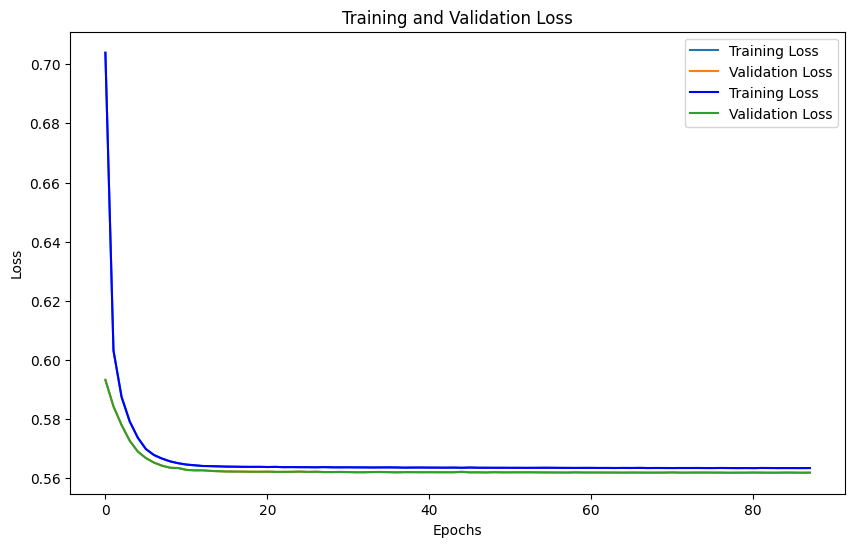

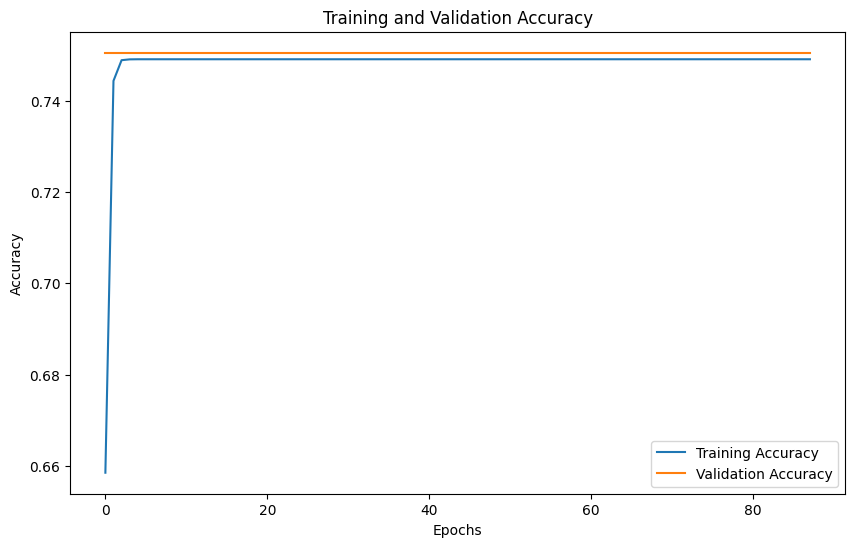

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.0001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0005),loss='binary_crossentropy',metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # Monitor validation loss, wait 10 epochs

history = model.fit(X_train_scaled, y_train, epochs=200, batch_size=128, validation_split=0.4, callbacks=[early_stopping]) # Add early stopping callback

loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy}")

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')

if 'loss' in history.history:
    plt.plot(history.history['loss'], label='Training Loss',color='blue')

if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Validation Loss')

plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
if 'accuracy' in history.history:
    plt.plot(history.history['accuracy'], label='Training Accuracy')

if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

2970/2970 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


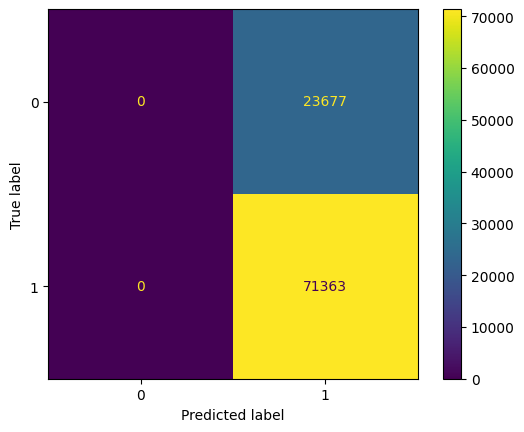

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)